<a href="https://colab.research.google.com/github/Rahmalyana/2025-Pengolahan-Citra/blob/main/Jobsheet_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEGMENTASI GAMBAR

## P1. Segmentasi Menggunakan Thresholding Global dan Otsu

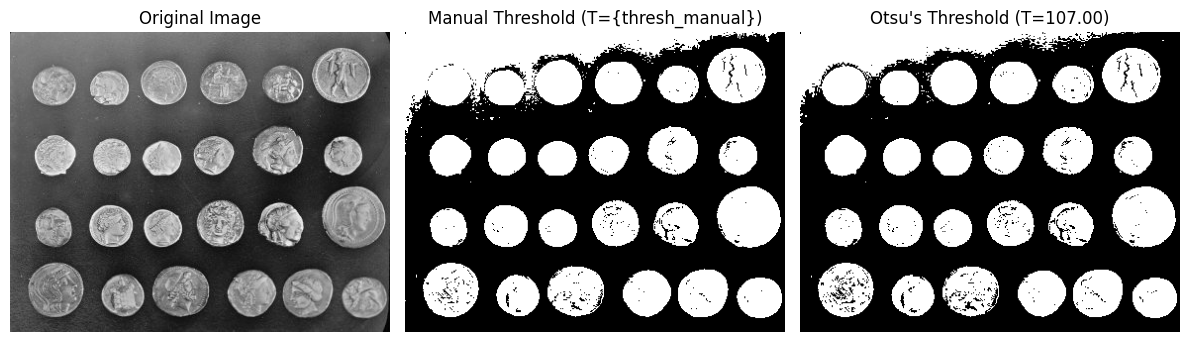

Nilai Threshold Otsu yang ditemukan: 107


In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

# 1. memuat citra
image_coins = data.coins()

# 2. thresholding global(manual)
thresh_manual = 100 #menentukan nilai ambang manual
binary_manual = image_coins > thresh_manual

# 3. thresholding otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

#4. visualisasi hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title('Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\'s Threshold (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

print (f"Nilai Threshold Otsu yang ditemukan: {thresh_otsu}")

## P2.Segmentasi Menggunakan Region Growing

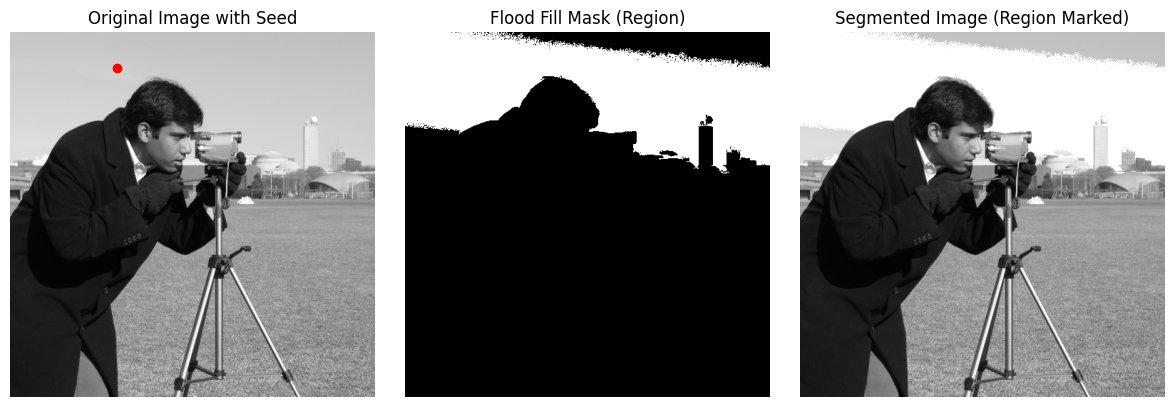

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. memuat citra
image_camera = data.camera()

# 2. tentukan titik 'seed'
# misal pilih titik area langit (koordinat y=50, x=150)
seed_point = (50,150)

# terapkan algoritma flood fill
      #tolreance menentukan seberapa besar perbedaan intensitas yang diinginkan
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. buat citra tersegmentasi
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255 #tandai region dengan warna putih

# 5. visualisasi hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro') # tandai seed putih
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title(f'Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## P3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering

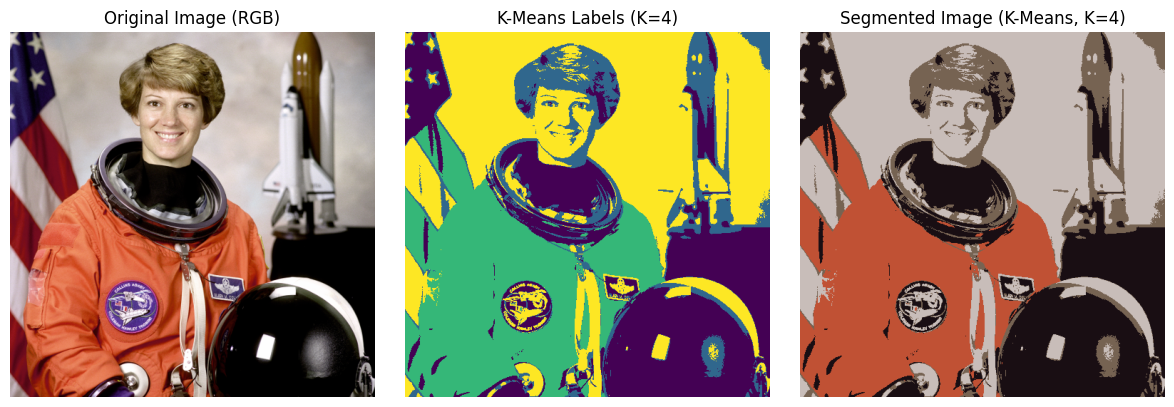

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. memuat citra berwarna
image_astro = data.astronaut()
#konversi ke float untuk perhitungan
image_astro_float = image_astro.astype(float) / 255.0

# 2. Reshape citra jadi array piksel [jumlah_pixel, jumlah_fitur]
# runag warna Lab biasanya lebih baik untuk persepsi warna
# konversi ke lab
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# terapkan k-means cluatering
# meneetukan jumlah cluster yg diinginkan, misal k=4
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10) #n_init='auto jika versi sklearn baru

# hiding future warning
with warnings.catch_warnings():
  warnings.simplefilter("ignore")
  pixel_labels = kmeans.fit_predict(pixel_features)

# 4. reshape label kembali ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. buat citra tersegmentasi (warnai setiap segment dgn warna rata2 cluster)
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range (n_clusters):
  #dapatkan piksel yg termasuk cluster k
  cluster_pixels = (pixel_labels == k)
  #isi pikel dgn citra baru dgn warna pusat cluster k
  # reshape kembali cluster_pikels ke bentuk citra
  mask_k = cluster_pixels.reshape(rows, cols)
  segmented_image_kmeans[mask_k] = centers_lab[k]

# konversi kembali ke RGB untuk ditampilkan
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# visualisai hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

# menampilkan label cluster
ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

# menampilkan citra hasil segmentasi k-means
ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()


## P4. Segmentasi Berbasis Watershed

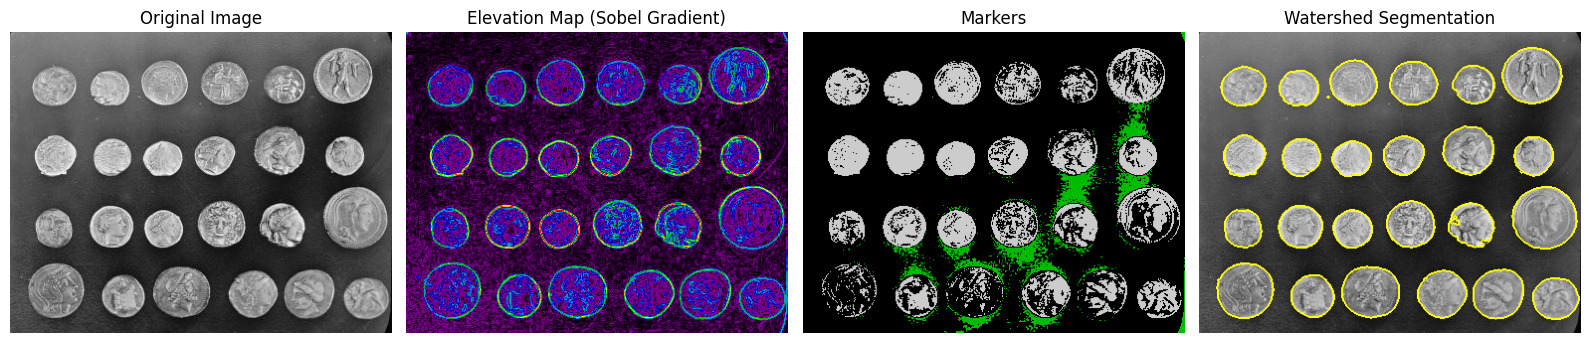

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

# 1. memuat citra
image_coins = data.coins()

# 2. hitung gradien citra (sebagai 'topografi)
elevation_map = filters.sobel(image_coins)

# 3. tentukan marker (penanda awal setiap cekungan/objek)
# Kita bisa menggunakan thresholding untuk mendapatkan marker kasar
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1 # marker untuk latar belakang
markers[image_coins > 150] = 2 # marker untuk latar objek (koin)

#  Atau gunakan marker dari local maxima (lebih canggih)

# 4. terapkan algoritma watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# warnai hasil segmentasi untuk visualisasi
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# visualisai hasil
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

## P5. Perbandingan Visualisasi Hasil Segmentasi

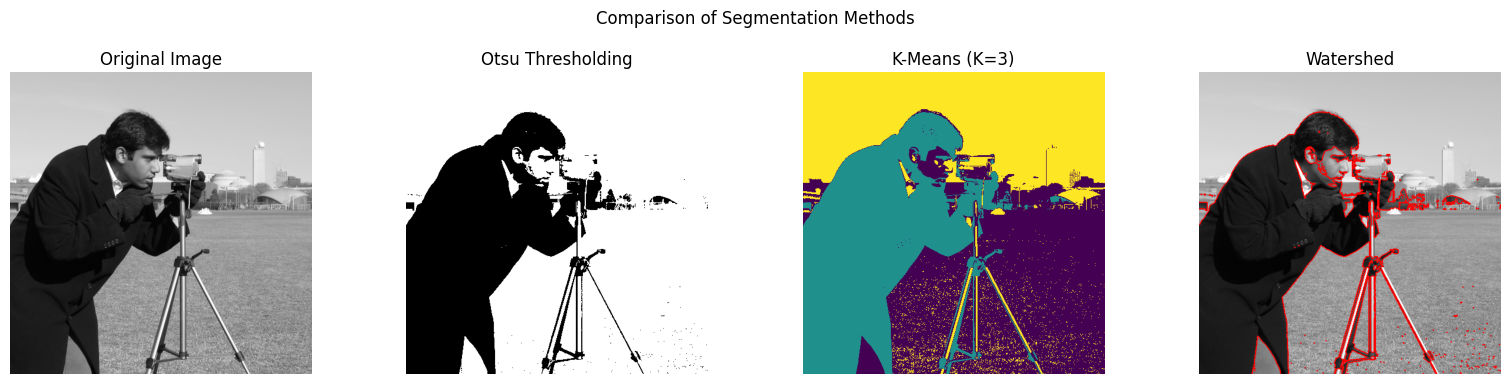

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. pilih citra untuk perbandingan
image = data.camera()
image_float = img_as_float(image)

# 2. lakukan bbrp metode segmentasi

# a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means (misal K=3)
# reshape untuk k-means (1 fitur:intensitas)
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
  warnings.simplefilter("ignore")
  pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) watershed (gunakan marker sederhana dari otsu)
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. visualisasi perbandingan
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap="viridis") #gunakan cmap berbeda utk label
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# gunakan mark_boundaries untuk watershed agar lebih jelas
segmented_watershed_colored = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1,0,0)) #batas merah

ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) #adjust layout to make space for suptitle
plt.show()

# PENUGASAN

## Eksperimen Thresholding

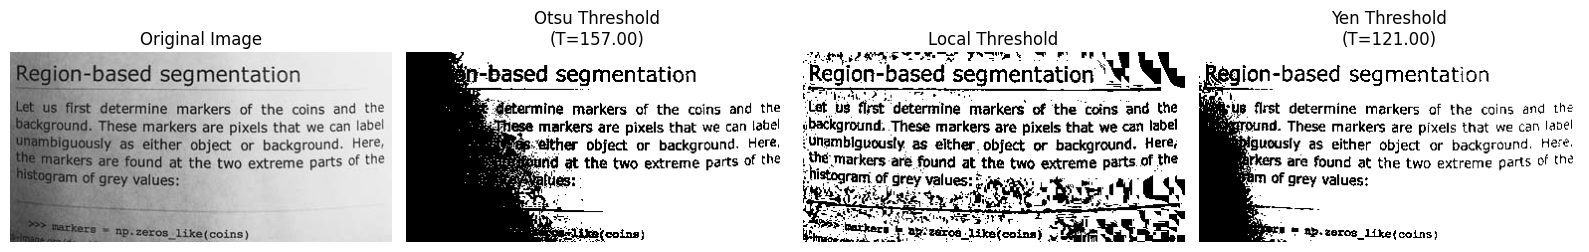

Nilai Threshold Otsu yang ditemukan: 157
Nilai Threshold Yen yang ditemukan: 121


In [1]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.color import rgb2gray

# 1. Memuat citra
image_page = data.page()

# 2. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_page)
binary_otsu = image_page > thresh_otsu

# 3. Thresholding Local
binary_local = filters.threshold_local(image_page, block_size=35)  # block_size bisa diatur
binary_local_result = image_page > binary_local

# 4. Thresholding Yen
thresh_yen = filters.threshold_yen(image_page)
binary_yen = image_page > thresh_yen

# 5. Visualisasi hasil
fig, axes = plt.subplots(ncols=4, figsize=(16, 4))
ax = axes.ravel()

ax[0].imshow(image_page, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title(f'Otsu Threshold\n(T={thresh_otsu:.2f})')
ax[1].axis('off')

ax[2].imshow(binary_local_result, cmap=plt.cm.gray)
ax[2].set_title('Local Threshold')
ax[2].axis('off')

ax[3].imshow(binary_yen, cmap=plt.cm.gray)
ax[3].set_title(f'Yen Threshold\n(T={thresh_yen:.2f})')
ax[3].axis('off')

plt.tight_layout()
plt.show()

print(f"Nilai Threshold Otsu yang ditemukan: {thresh_otsu}")
print(f"Nilai Threshold Yen yang ditemukan: {thresh_yen}")


## Menerapkan 3 metode segmentasi ke citra

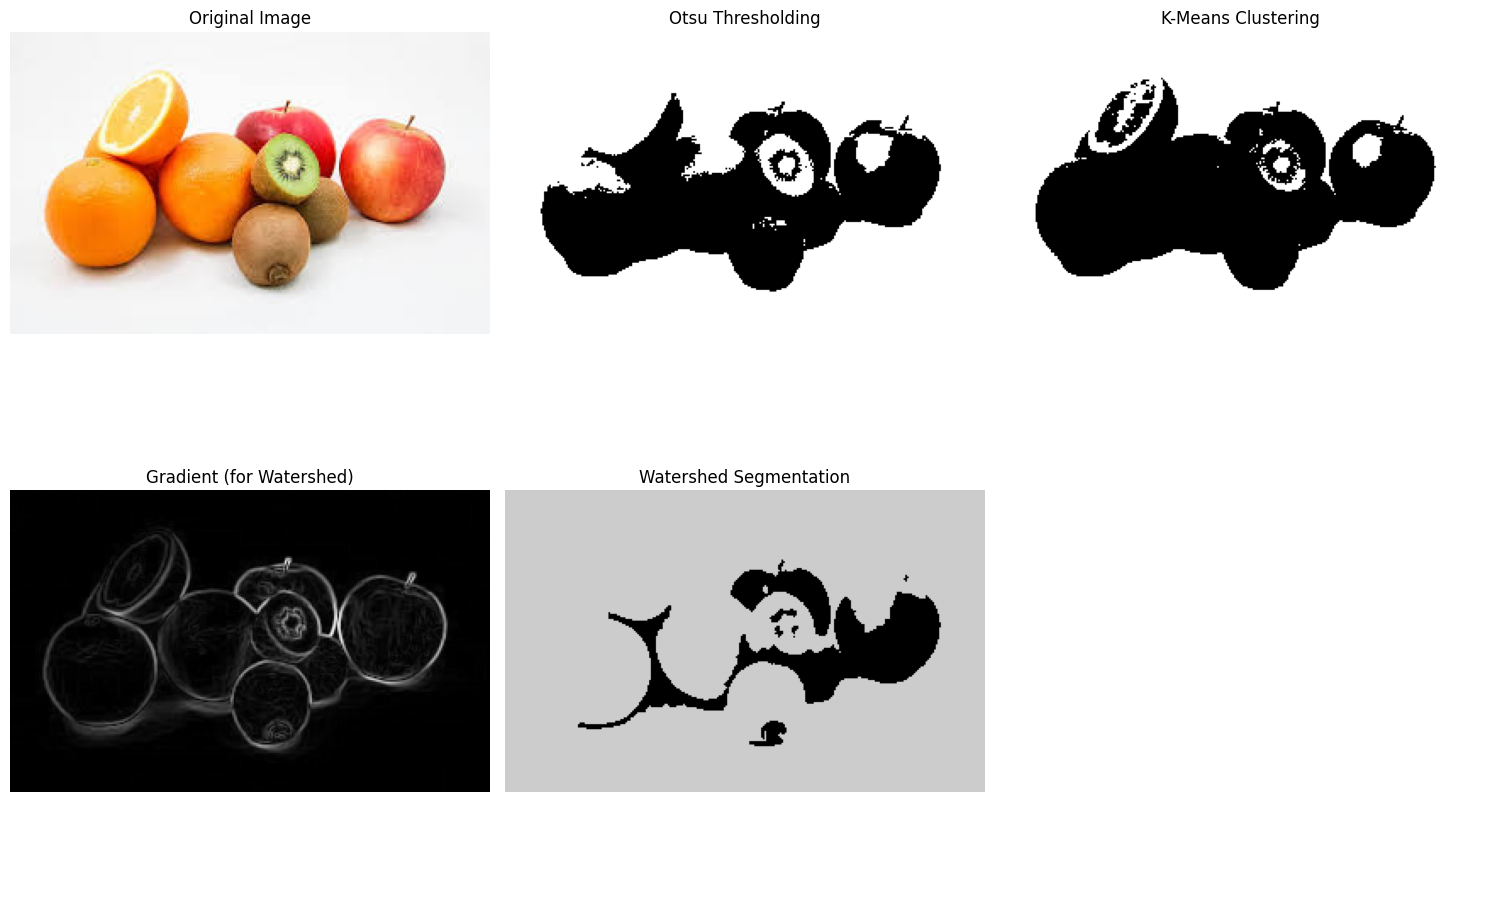

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io, color, filters, segmentation, morphology, feature
from sklearn.cluster import KMeans
from scipy import ndimage as ndi

# 1. Load citra
image = io.imread('buah.jpg')  # pastikan file ini ada di folder yang sama
image_gray = color.rgb2gray(image)

# 2. Segmentasi Otsu
thresh_otsu = filters.threshold_otsu(image_gray)
binary_otsu = image_gray > thresh_otsu

# 3. Segmentasi K-Means
pixels = image.reshape(-1, 3)  # reshape ke array 2D (n_pixel, n_channel)
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(pixels)
segmented_img_kmeans = kmeans.labels_.reshape(image.shape[:2])

# 4. Segmentasi Watershed
# Gradient dari gambar grayscale
gradient = filters.sobel(image_gray)

# Membuat markers manual
markers = np.zeros_like(image_gray, dtype=np.int32)
markers[image_gray < 0.3] = 1  # background (gelap)
markers[image_gray > 0.7] = 2  # foreground (terang)

# Watershed
segmentation_ws = segmentation.watershed(gradient, markers)

# 5. Visualisasi hasil
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
ax = axes.ravel()

ax[0].imshow(image)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_img_kmeans, cmap='gray')
ax[2].set_title('K-Means Clustering')
ax[2].axis('off')

ax[3].imshow(gradient, cmap='gray')
ax[3].set_title('Gradient (for Watershed)')
ax[3].axis('off')

ax[4].imshow(segmentation_ws, cmap='nipy_spectral')
ax[4].set_title('Watershed Segmentation')
ax[4].axis('off')

ax[5].axis('off')  # kosongkan 1 plot

plt.tight_layout()
plt.show()
